# Jaguar Karaoke Analysis

## Overview

This notebook analyzes reservation data from Jaguar Karaoke to understand demand patterns and room utilization across Berkeley and Oakland locations.

Key findings:
- Peak demand occurs between 8PM–10PM
- Oakland shows stronger reservation-based demand
- Berkeley likely relies more on walk-in customers
- Reservation data underestimates true utilization

Note: This analysis is based only on reservation data and does not include walk-in customers.

## Business Overview

This project analyzes reservation data from a private-room karaoke business with two locations in Berkeley and Oakland, California. The business offers multiple room types with varying capacities and operates daily from 6 PM to 2 AM.

Pricing is based on group size and duration, with additional revenue generated from beverages and snacks.

The goal of this analysis is to understand demand patterns, room utilization, and operational efficiency, and to identify opportunities to improve performance.

---

## Project Objectives

This analysis focuses on three key areas:

**1. Demand & Revenue Drivers**
- Identify peak hours and key factors influencing usage (e.g., group size, duration)
- Evaluate how demand varies across locations

**2. Operational Efficiency**
- Measure room utilization across time
- Identify underutilized periods and capacity gaps

**3. Data Limitations & Insights**
- Assess limitations in the current data (e.g., no walk-in tracking, no item-level sales)
- Translate data gaps into business impact and improvement opportunities

## Data Overview

The dataset consists of reservation-level records from two locations (Berkeley and Oakland). Each row represents a single booking.

Key variables include:
- Date: reservation date
- Start / End Time: booking time window
- Duration: length of session (engineered)
- Group Size: number of customers per reservation
- Location: Berkeley or Oakland
- Room: room identifier or type
- Total Spend: total amount spent per group (when available)

### Data Challenges
- Inconsistent time formats required parsing and standardization
- Missing end times in some cases required estimation using duration
- No customer identifiers → cannot track repeat behavior
- No item-level data → cannot analyze drink/food preferences
- Walk-in customers not captured → utilization is underestimated

## Data Cleaning

The raw reservation data required several preprocessing steps before analysis:

- Standardized inconsistent column names across Berkeley and Oakland datasets  
- Removed unnecessary columns generated during export  
- Combined datasets into a single dataframe with a location indicator  
- Forward-filled missing dates to maintain continuity  
- Removed rows with missing check-in times  

These steps ensure consistency and allow for accurate time-based analysis.

In [15]:
import pandas as pd
import re

# Load data
oak = pd.read_csv('Reservation_Jaguar  - March Oakland.csv')
berk = pd.read_csv('Reservation_Jaguar  - March Berkeley.csv')

# Standardize column names before combining
oak = oak.rename(columns={'Oakland': 'Check_in'})
berk = berk.rename(columns={'Check-in': 'Check_in'})

# Drop junk columns from Berkeley
berk = berk.drop(columns=['Unnamed: 7', 'Unnamed: 8'])

# Add location
oak['location'] = 'Oakland'
berk['location'] = 'Berkeley'

# Combine
df = pd.concat([oak, berk], ignore_index=True)

# Forward fill dates
df['Date'] = df['Date'].ffill()

# Drop rows without check-in
df = df[df['Check_in'].notna()].copy()

In [16]:
print(df.info())
print(df.isna().sum())

<class 'pandas.core.frame.DataFrame'>
Index: 215 entries, 0 to 374
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Date           215 non-null    object
 1   Check_in       215 non-null    object
 2   Room #         112 non-null    object
 3   Confirmed?     50 non-null     object
 4   Date Received  104 non-null    object
 5   by whom        151 non-null    object
 6   Notes          45 non-null     object
 7   location       215 non-null    object
dtypes: object(8)
memory usage: 15.1+ KB
None
Date               0
Check_in           0
Room #           103
Confirmed?       165
Date Received    111
by whom           64
Notes            170
location           0
dtype: int64


### Data Quality Check

- Core fields such as date and check-in time are complete  
- Several operational fields (e.g., room assignment, confirmation status, notes) contain significant missing values  
- Missing values suggest inconsistent data entry practices and limit deeper operational analysis  

## Feature Engineering

To make the reservation data analyzable, I transformed unstructured booking text into structured variables such as start time, end time, group size, phone number, duration, and weekday. I also converted ambiguous evening and overnight times into a consistent business hour scale to support demand and utilization analysis.

In [17]:
def parse_checkin(text):
    text = str(text).strip()

    # normalize weird formats
    text = text.replace('~', '-')
    text = re.sub(r'(\d)\s+(\d{2})', r'\1:\2', text)

    # special case like 3:30/4:30-6:30
    slash_match = re.search(r'(\d{1,2}:\d{2})/(\d{1,2}:\d{2})-(\d{1,2}:\d{2})', text)
    if slash_match:
        start = slash_match.group(2)
        end = slash_match.group(3)
    else:
        time_match = re.search(r'(\d{1,2}:\d{2})(?:-(\d{1,2}:\d{2}))?', text)
        start = time_match.group(1) if time_match else None
        end = time_match.group(2) if time_match and time_match.group(2) else None

    group_match = re.search(r'(\d+)-?(\d+)?ppl', text)
    if group_match:
        g1 = int(group_match.group(1))
        g2 = group_match.group(2)
        group_size = (g1 + int(g2)) / 2 if g2 else g1
    else:
        group_size = None

    phone_match = re.search(r'\d{3}-\d{3}-\d{4}', text)
    phone = phone_match.group(0) if phone_match else None

    return pd.Series({
        'start_time': start,
        'end_time': end,
        'group_size': group_size,
        'phone': phone
    })

In [18]:
parsed = df['Check_in'].apply(parse_checkin)
df = pd.concat([df, parsed], axis=1)

In [19]:
df[['Date', 'location', 'Check_in', 'start_time', 'end_time', 'group_size', 'phone']].head(15)

,Date,location,Check_in,start_time,end_time,group_size,phone
0,"Sunday, 03/01",Oakland,3:30/4:30-6:30 15ppl Lori 609-498-4868,4:30,6:30,15.0,609-498-4868
1,"Sunday, 03/01",Oakland,6:30-8:00 10ppl Madison 978-994-3486,6:30,8:00,10.0,978-994-3486
2,"Sunday, 03/01",Oakland,10:00-2:00 14-15ppl Mera Maselli 510-755-9703,10:00,2:00,14.5,510-755-9703
3,"Sunday, 03/01",Oakland,8:30-11:30 8-10ppl Nick 603-848-4064,8:30,11:30,9.0,603-848-4064
4,"Sunday, 03/01",Oakland,7:00 4ppl Julia 510-561-5030,7:00,None,4.0,510-561-5030
8,"Tuesday, 03/03",Oakland,8:00 3-4ppl Jade 650-303-1356,8:00,None,3.5,650-303-1356
9,"Tuesday, 03/03",Oakland,9:00 8-10ppl Story 303-862-0015,9:00,None,9.0,303-862-0015
15,"Friday, 03/06",Oakland,9:30-11:30 8ppl Emily Murffy 925-594-9491,9:30,11:30,8.0,925-594-9491
16,"Friday, 03/06",Oakland,9:30-11:30 10-12ppl Mamu 628-205-7863,9:30,11:30,11.0,628-205-7863
17,"Friday, 03/06",Oakland,8:30-11:30 12ppl Omar 415-859-8065,8:30,11:30,12.0,415-859-8065


### Time Standardization for Business Hours

Because Jaguar operates during evening and overnight hours (6 PM–2 AM), raw timestamps can be ambiguous and cross midnight.

To address this, I converted all times into a continuous "business hour" scale, where:
- 6 PM = 18
- Midnight = 24
- 2 AM = 26

This allows accurate calculation of session duration and enables consistent time-based analysis.

In [20]:
# Because the business operates in the evening and late night hours,
# I adjusted time parsing logic to correctly interpret ambiguous timestamps and handle overnight sessions.

def to_business_hour(t):
    if pd.isna(t) or t is None:
        return None
    
    t = str(t).strip()
    hour, minute = map(int, t.split(':'))
    value = hour + minute / 60

    # 3 PM – 11 PM
    if 3 <= hour <= 11:
        value += 12
    
    # midnight (12:00 AM)
    elif hour == 12:
        value = 24 + minute / 60
    
    # 1 AM – 2:59 AM
    elif 0 <= hour < 3:
        value += 24
    
    return value

df['start_hour_num'] = df['start_time'].apply(to_business_hour)
df['end_hour_num'] = df['end_time'].apply(to_business_hour)

df['duration_hours'] = df['end_hour_num'] - df['start_hour_num']
df.loc[df['duration_hours'] <= 0, 'duration_hours'] = None

df[['Check_in', 'start_time', 'end_time', 'start_hour_num', 'end_hour_num', 'duration_hours']].head(15)

,Check_in,start_time,end_time,start_hour_num,end_hour_num,duration_hours
0,3:30/4:30-6:30 15ppl Lori 609-498-4868,4:30,6:30,16.5,18.5,2.0
1,6:30-8:00 10ppl Madison 978-994-3486,6:30,8:00,18.5,20.0,1.5
2,10:00-2:00 14-15ppl Mera Maselli 510-755-9703,10:00,2:00,22.0,26.0,4.0
3,8:30-11:30 8-10ppl Nick 603-848-4064,8:30,11:30,20.5,23.5,3.0
4,7:00 4ppl Julia 510-561-5030,7:00,None,19.0,NaN,NaN
8,8:00 3-4ppl Jade 650-303-1356,8:00,None,20.0,NaN,NaN
9,9:00 8-10ppl Story 303-862-0015,9:00,None,21.0,NaN,NaN
15,9:30-11:30 8ppl Emily Murffy 925-594-9491,9:30,11:30,21.5,23.5,2.0
16,9:30-11:30 10-12ppl Mamu 628-205-7863,9:30,11:30,21.5,23.5,2.0
17,8:30-11:30 12ppl Omar 415-859-8065,8:30,11:30,20.5,23.5,3.0


In [23]:
df['Date_clean'] = df['Date'].astype(str).str.extract(r'(\d{2}/\d{2})')
df['Date_parsed'] = pd.to_datetime(df['Date_clean'], format='%m/%d', errors='coerce')
df['weekday'] = df['Date_parsed'].dt.day_name()

In [24]:
df[['Check_in', 'start_time', 'end_time', 'duration_hours']].head(15)

,Check_in,start_time,end_time,duration_hours
0,3:30/4:30-6:30 15ppl Lori 609-498-4868,4:30,6:30,2.0
1,6:30-8:00 10ppl Madison 978-994-3486,6:30,8:00,1.5
2,10:00-2:00 14-15ppl Mera Maselli 510-755-9703,10:00,2:00,4.0
3,8:30-11:30 8-10ppl Nick 603-848-4064,8:30,11:30,3.0
4,7:00 4ppl Julia 510-561-5030,7:00,None,NaN
8,8:00 3-4ppl Jade 650-303-1356,8:00,None,NaN
9,9:00 8-10ppl Story 303-862-0015,9:00,None,NaN
15,9:30-11:30 8ppl Emily Murffy 925-594-9491,9:30,11:30,2.0
16,9:30-11:30 10-12ppl Mamu 628-205-7863,9:30,11:30,2.0
17,8:30-11:30 12ppl Omar 415-859-8065,8:30,11:30,3.0


In [25]:
df.groupby('location')['Date_clean'].nunique()

location
Berkeley    16
Oakland     18
Name: Date_clean, dtype: int64

## Section: Analysis

In [11]:
# hour (rounded down)
df['start_hour'] = df['start_hour_num'].apply(lambda x: int(x) if pd.notna(x) else None)

In [12]:
df

,Date,Check_in,Room #,Confirmed?,Date Received,by whom,Notes,location,start_time,end_time,group_size,phone,duration_hours,start_hour_num,end_hour_num,Date_clean,Date_parsed,weekday,start_hour
0,"Sunday, 03/01",3:30/4:30-6:30 15ppl Lori 609-498-4868,Cancelled,NaN,01/19/2026,Nick,텍스트 / 직접와서 보고 예약함,Oakland,4:30,6:30,15.0,609-498-4868,2.0,16.5,18.5,03/01,1900-03-01,Thursday,16.0
1,"Sunday, 03/01",6:30-8:00 10ppl Madison 978-994-3486,#5,NaN,02/06/2026,Nick,보이스메일/ 텍스트,Oakland,6:30,8:00,10.0,978-994-3486,1.5,18.5,20.0,03/01,1900-03-01,Thursday,18.0
2,"Sunday, 03/01",10:00-2:00 14-15ppl Mera Maselli 510-755-9703,#9,NaN,02/22/2026,Nick,NaN,Oakland,10:00,2:00,14.5,510-755-9703,4.0,22.0,26.0,03/01,1900-03-01,Thursday,22.0
3,"Sunday, 03/01",8:30-11:30 8-10ppl Nick 603-848-4064,#8,NaN,03/01/2026,Nick,NaN,Oakland,8:30,11:30,9.0,603-848-4064,3.0,20.5,23.5,03/01,1900-03-01,Thursday,20.0
4,"Sunday, 03/01",7:00 4ppl Julia 510-561-5030,#3,NaN,NaN,Nick,NaN,Oakland,7:00,None,4.0,510-561-5030,NaN,19.0,NaN,03/01,1900-03-01,Thursday,19.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
353,Saturday 03/21,9:30-11:30 20ppl Fernando 925-482-5334,NaN,NaN,03/09/2026,Nick,텍스트,Berkeley,9:30,11:30,20.0,925-482-5334,2.0,21.5,23.5,03/21,1900-03-21,Wednesday,21.0
354,Saturday 03/21,8:00-12:00 8ppl Kristyn Merritt 647-642-5606,NaN,NaN,03/17/2026,Nick,텍스트,Berkeley,8:00,12:00,8.0,647-642-5606,4.0,20.0,24.0,03/21,1900-03-21,Wednesday,20.0
355,Saturday 03/21,7:00-9:00 2ppl Hinako 509-308-8086,NaN,NaN,03/18/2026,Nick,NaN,Berkeley,7:00,9:00,2.0,509-308-8086,2.0,19.0,21.0,03/21,1900-03-21,Wednesday,19.0
373,Friday 04/03,10:00-12:00 20ppl Malaia Reger 714-357-1051,NaN,NaN,03/17/2026,Nick,NaN,Berkeley,10:00,12:00,20.0,714-357-1051,2.0,22.0,24.0,04/03,1900-04-03,Tuesday,22.0


In [13]:
df[['Date', 'Date_clean', 'Date_parsed', 'weekday']].head(10)

,Date,Date_clean,Date_parsed,weekday
0,"Sunday, 03/01",03/01,1900-03-01,Thursday
1,"Sunday, 03/01",03/01,1900-03-01,Thursday
2,"Sunday, 03/01",03/01,1900-03-01,Thursday
3,"Sunday, 03/01",03/01,1900-03-01,Thursday
4,"Sunday, 03/01",03/01,1900-03-01,Thursday
8,"Tuesday, 03/03",03/03,1900-03-03,Saturday
9,"Tuesday, 03/03",03/03,1900-03-03,Saturday
15,"Friday, 03/06",03/06,1900-03-06,Tuesday
16,"Friday, 03/06",03/06,1900-03-06,Tuesday
17,"Friday, 03/06",03/06,1900-03-06,Tuesday


## Section: Peak Hour Demand

In [14]:
hour_counts = df['start_hour'].value_counts().sort_index()
hour_counts

start_hour
13.0     4
16.0     2
18.0    14
19.0    31
20.0    38
21.0    34
22.0    35
23.0    28
24.0    24
25.0     1
Name: count, dtype: int64

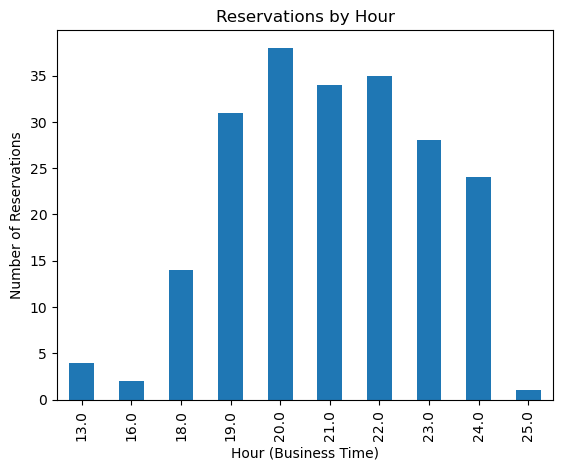

In [15]:
import matplotlib.pyplot as plt

hour_counts.plot(kind='bar')
plt.title('Reservations by Hour')
plt.xlabel('Hour (Business Time)')
plt.ylabel('Number of Reservations')
plt.show()

## 📄 Insight: Demand Patterns

> Reservation demand is heavily concentrated between 8 PM and 11 PM, with a clear peak around 9–10 PM. Early hours (6–7 PM) show relatively low utilization, and demand drops significantly after midnight.
>
> This suggests that the business operates with strong peak-hour pressure but underutilized capacity during early evening hours.

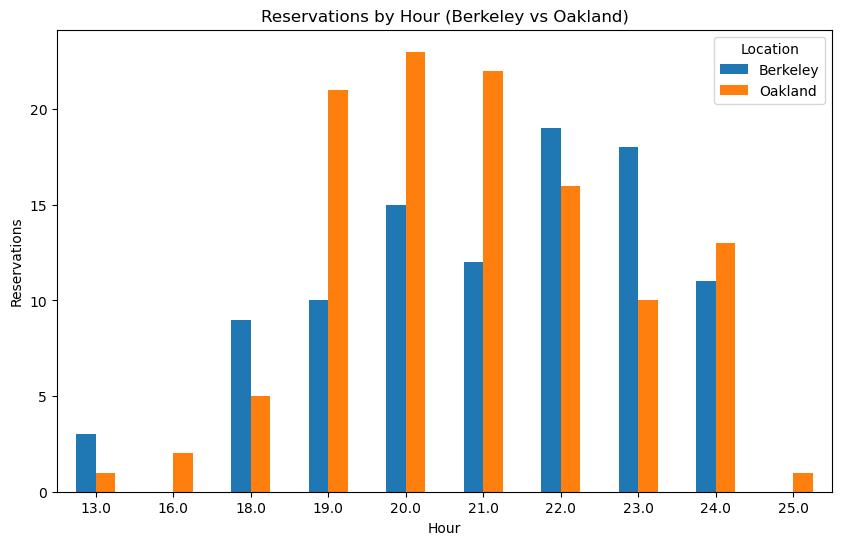

In [16]:
location_hour = df.groupby(['location', 'start_hour']).size().unstack(fill_value=0)

location_hour.T.plot(kind='bar', figsize=(10,6))

plt.title('Reservations by Hour (Berkeley vs Oakland)')
plt.xlabel('Hour')
plt.ylabel('Reservations')
plt.xticks(rotation=0)
plt.legend(title='Location')
plt.show()

## What this chart suggests

### Oakland

Oakland seems to peak earlier, especially around **7 PM to 9 PM**, and appears stronger in the early evening.

### Berkeley

Berkeley seems to pick up later and stays stronger around **10 PM to 11 PM**.

### Shared pattern

Both locations drop sharply after midnight, which suggests the most valuable hours are still concentrated before closing.

> Demand patterns differ across locations. Oakland shows stronger early evening demand, with reservations peaking around 7 PM to 9 PM, while Berkeley appears to peak later, especially around 10 PM to 11 PM. This suggests that customer traffic timing may vary by location, which could have implications for staffing, promotions, and room allocation strategies.

## 📄 Insight: Customer Segmentation by Location

> Reservation patterns differ significantly across locations. Oakland shows stronger early evening demand, peaking between 7 PM and 9 PM, likely driven by an older customer base that prefers earlier outings. In contrast, Berkeley peaks later, around 10 PM to 11 PM, reflecting student-driven demand that skews toward late-night activity.
>
> These differences suggest that customer behavior varies by location, which has direct implications for operational decisions such as opening hours, promotions, and resource allocation.

> Early evening hours (6–7 PM) show consistently low demand, suggesting potential inefficiency in operating during this period. However, occasional reservations during this window indicate that fully eliminating the hour may risk lost revenue. A more flexible approach, such as delayed opening on low-demand weekdays or conditional opening based on reservations, could improve cost efficiency.

---

### Idea 2: happy hour / promotion

> To address low utilization during early hours, targeted promotions such as discounted room rates or drink specials (“happy hour”) between 6 PM and 8 PM could help shift demand earlier and improve overall capacity utilization.


## 📄 Final Recommendation

> To improve utilization during early evening hours, the business could introduce targeted promotions such as discounted rates or bundled drink offers between 6 PM and 8 PM. If demand remains consistently low, management could consider adjusting opening hours on weekdays to reduce operational costs. A data-driven approach that tests promotional effectiveness before changing hours would minimize revenue risk while improving efficiency.

## Section: Utilization

In [17]:
booked_hours = df.groupby('location')['duration_hours'].sum()
booked_hours

location
Berkeley    115.0
Oakland     175.5
Name: duration_hours, dtype: float64

In [18]:
days = df.groupby('location')['Date_clean'].nunique()
days

location
Berkeley    16
Oakland     18
Name: Date_clean, dtype: int64

In [19]:
room_counts = {
    'Berkeley': 13,
    'Oakland': 9
}

In [20]:
util = pd.DataFrame({
    'booked_hours': booked_hours,
    'days': days
})

util['rooms'] = util.index.map(room_counts)
util['capacity_hours'] = util['days'] * util['rooms'] * 8
util['utilization_rate'] = util['booked_hours'] / util['capacity_hours']

util

,booked_hours,days,rooms,capacity_hours,utilization_rate
location,,,,,
Berkeley,115.0,16,13,1664,0.069111
Oakland,175.5,18,9,1296,0.135417


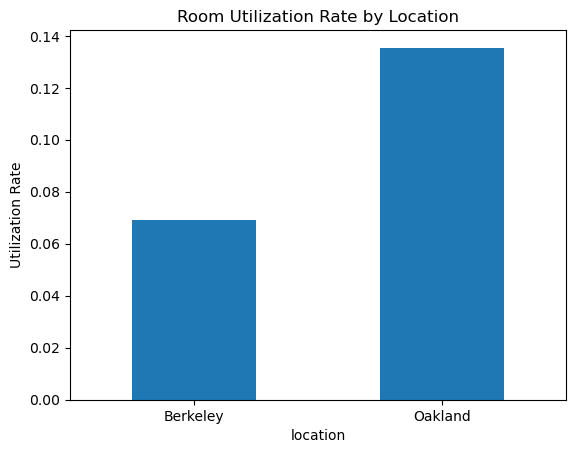

In [21]:
util['utilization_rate'].plot(kind='bar')
plt.title('Room Utilization Rate by Location')
plt.ylabel('Utilization Rate')
plt.xticks(rotation=0)
plt.show()

In [22]:
df[df['location'] == 'Berkeley'][['Date', 'Date_clean', 'Date_parsed']].head(20)

,Date,Date_clean,Date_parsed
230,Sunday 03/01,03/01,1900-03-01
231,Sunday 03/01,03/01,1900-03-01
237,Wednesday 03/04,03/04,1900-03-04
239,Thursday 03/05,03/05,1900-03-05
241,Friday 03/06,03/06,1900-03-06
242,Friday 03/06,03/06,1900-03-06
243,Friday 03/06,03/06,1900-03-06
244,Friday 03/06,03/06,1900-03-06
245,Friday 03/06,03/06,1900-03-06
246,Friday 03/06,03/06,1900-03-06


## Final Insight: Capacity Utilization

> Both locations exhibit low overall utilization rates, with Berkeley operating at approximately 7% and Oakland at around 13.5% of total available room capacity. This indicates that a significant portion of available room hours remains unused.
>
> Despite strong peak-hour demand, especially in late evening hours, capacity usage is highly concentrated within a narrow time window, leaving early evening hours underutilized.
>
> It is important to note that these estimates are likely conservative, as the dataset primarily captures reservation-based bookings and may not fully reflect walk-in traffic.
---

## Recommendation

> To improve overall utilization, the business could implement targeted promotions such as discounted room rates or drink specials during low-demand hours (e.g., 6–8 PM). This may help shift demand earlier and better distribute usage across available time slots.
>
> If early-hour utilization remains consistently low, management could consider adjusting weekday operating hours to reduce labor and operational costs. A data-driven approach that tests promotional strategies before modifying hours would minimize revenue risk while improving efficiency.

# Heatmap

In [27]:
# Step 1: make sure your source rows are clean
# Before rebuilding the heatmap, filter out bad rows:
heat_df = df.copy()

heat_df = heat_df[
    heat_df['start_hour_num'].notna() &
    heat_df['duration_hours'].notna() &
    (heat_df['duration_hours'] > 0)
].copy()

# And create a usable end hour:
heat_df['end_hour_filled'] = heat_df['end_hour_num'].fillna(
    heat_df['start_hour_num'] + heat_df['duration_hours']
)

In [29]:
# expand each reservation into hourly slots, but keep the date
rows = []

for _, row in heat_df.iterrows():
    start = int(row['start_hour_num'])
    end = int(row['end_hour_filled'])

    if end > start:
        for h in range(start, end):
            rows.append({
                'location': row['location'],
                'date': row['Date_clean'],
                'hour': h
            })

hourly_df = pd.DataFrame(rows)
hourly_df.head()

,location,date,hour
0,Oakland,03/01,16
1,Oakland,03/01,17
2,Oakland,03/01,18
3,Oakland,03/01,19
4,Oakland,03/01,22


In [31]:
# count rooms occupied by date and hour

daily_hour_counts = (
    hourly_df.groupby(['location', 'date', 'hour'])
    .size()
    .reset_index(name='rooms_occupied')
)

daily_hour_counts.head(20)

#Now each row means:
#For this location, on this specific date, at this specific hour, how many reservations were occupying rooms.
#That is something you can actually interpret.

,location,date,hour,rooms_occupied
0,Berkeley,03/01,18,2
1,Berkeley,03/01,19,2
2,Berkeley,03/06,18,1
3,Berkeley,03/06,19,1
4,Berkeley,03/06,20,1
5,Berkeley,03/06,21,1
6,Berkeley,03/06,22,2
7,Berkeley,03/06,23,2
8,Berkeley,03/07,18,2
9,Berkeley,03/07,19,4


In [32]:
# average across days

avg_hour_counts = (
    daily_hour_counts.groupby(['location', 'hour'])['rooms_occupied']
    .mean()
    .unstack(fill_value=0)
)

In [33]:
# convert to utilization rate

room_counts = {'Berkeley': 13, 'Oakland': 9}

avg_util = avg_hour_counts.astype(float).copy()

for loc in avg_util.index:
    avg_util.loc[loc] = avg_util.loc[loc] / room_counts[loc]

avg_util = avg_util.clip(upper=1)
avg_util

hour,16,17,18,19,20,21,22,23,24,25
location,,,,,,,,,,
Berkeley,0.000000,0.000000,0.123077,0.205128,0.221154,0.207692,0.222222,0.164835,0.000000,0.000000
Oakland,0.111111,0.111111,0.111111,0.222222,0.373737,0.522222,0.411111,0.234568,0.222222,0.111111


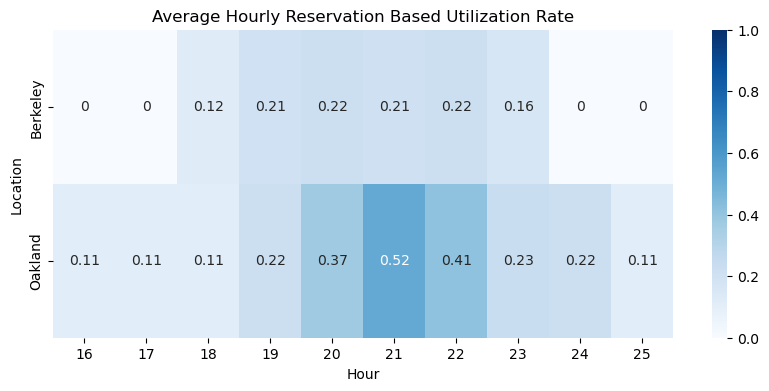

In [34]:
#Heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
sns.heatmap(avg_util, annot=True, cmap='Blues', vmin=0, vmax=1)
plt.title('Average Hourly Reservation Based Utilization Rate')
plt.xlabel('Hour')
plt.ylabel('Location')
plt.show()

# What these numbers mean

Each cell = **average % of rooms occupied by reservations at that hour**

So:

* **0.52 (Oakland at 21:00)**
  → ~52% of rooms are reserved at 9PM on an average day

* **0.22 (Berkeley at 20:00)**
  → ~22% of rooms are reserved at 8PM

---

# CRITICAL interpretation

> **reservation-based utilization ONLY**

Because:

* Walk-ins are missing
* walk-ins dominate

---

# Key insights

## 1. Oakland has much stronger reservation demand

* Peaks around **21–22 (9–10PM)**:

  * ~52% → very high for reservation-only data
* Even earlier hours (20:00) already strong (~37%)

> Oakland has more structured / planned group demand

---

## 2. Berkeley reservation demand is weak

* Peaks only around:

  * ~20–22% max
* Mostly low across all hours

> Berkeley relies heavily on **walk-ins instead of reservations**

This matches real-world observation

---

## 3. Peak hours are clear (even with incomplete data)

Both locations show:
Peak = **20:00 – 22:00**

Even with missing walk-in data:

> Demand concentration is still visible

---

## 4. Huge unused reservation capacity


> Reservation data significantly underestimates true utilization, especially in Berkeley, where operational experience suggests a higher reliance on walk-in customers. However, the data still reveals clear peak demand hours (8PM–10PM) and stronger structured demand in Oakland.

---

# Business insights

## 1. Pricing opportunity

* Peak hours are known → dynamic pricing possible

## 2. Reservation system underutilized

* Especially Berkeley
* Could increase:

  * online booking
  * event packages

## 3. Oakland vs Berkeley strategy difference

Oakland:

* reservation-driven
* group-based demand

Berkeley:

* walk-in heavy
* spontaneous demand

---
Multiply utilization × room count

Example:

* Oakland 0.52 × 9 rooms ≈ ~4.7 rooms reserved at peak

## Section: Data Limitations & Improvement Opportunities

### Data Limitations

> The dataset contains several structural limitations that restrict the depth of analysis. For example, no-show reservations are indicated through cell color formatting rather than an explicit field, making them unobservable after data export. Additionally, key variables such as customer identifiers, item-level purchases, and revenue per reservation are not consistently captured.

---

### Data Structure Issues

> The data also lacks standardization across locations. Berkeley and Oakland datasets use different formats for dates and reservation entries, requiring additional preprocessing to align schemas. Furthermore, important attributes such as reservation time, group size, and customer information are embedded within a single text field, reducing data usability and increasing parsing complexity.

---

### Recommended Improvements


#### 1. Add explicit “No-Show” indicator

> Replace color-based encoding with a dedicated “no_show” column to ensure consistent and analyzable tracking of reservation outcomes.

---

#### 2. Standardize schema across locations

> Align column names and formats (e.g., date, time, room number) across all branches to improve data consistency and reduce preprocessing effort.

---

#### 3. Normalize reservation data structure

Instead of:

```text
"6:30-8:00 10ppl Madison 978-994-3486"
```

Have:

* start_time
* end_time
* group_size
* customer_name
* phone_number

---

#### 4. Use 24-hour time format

> Store all time variables in a consistent 24-hour format to eliminate ambiguity and simplify analysis.

---

#### 5. Capture revenue data (VERY strong point)

> Recording total spend per reservation (and ideally item-level purchases) would enable analysis of revenue drivers, pricing effectiveness, and customer behavior.

---

> These improvements would transform the dataset from a basic operational log into a structured analytics asset, enabling more advanced analysis and data-driven decision-making.

> Without structured data collection, the business cannot accurately measure customer retention, no-show rates, or revenue drivers, limiting its ability to optimize pricing, promotions, and operations.

## SECTION 2: What the data CANNOT show

> Reservation data does not fully capture actual operations. Based on on-site experience, a significant portion of customers in Berkeley are walk-ins, which are not recorded in the reservation dataset.

---

## SECTION 3: High-value operational insights

### Insight 1: Walk-in demand (Berkeley vs Oakland)

**Observation:**

* Berkeley → more walk-ins (students, spontaneous)
* Oakland → more reservation-based (older customers)

**Problem:**

* Current dataset **underestimates Berkeley demand**

**Recommendation:**

* Add `walk_in_flag` or separate walk-in log

**Business impact:**

* Better staffing decisions
* More accurate demand forecasting

---

### Insight 2: Lost revenue from outside food & drinks

**Observation:**

* Many customers bring outside food/drinks
* No tracking → no monetization

**Problem:**

* Major revenue leakage

**Recommendations:**

1. Track:

   * `outside_food_flag`
   * `outside_drink_flag`

2. Introduce:

   * corkage fee OR
   * bundle deals (room + drinks)

**Business impact:**

* Direct revenue increase

---

### Insight 3: Revenue model misalignment

> “karaoke business should profit off drinks not room”

**Current model:**

* Revenue mostly from room pricing

**Opportunity:**

* Increase per-customer spend via drinks

**Recommendations:**

* Happy hour (6–8 PM low demand time)
* Drink bundles:

  * “$X room + 2 soju”
* Upsell prompts during booking

---

### Insight 4: Restaurant collaboration

**Reality:**

* Customers already bring outside food

**Opportunity:**

* Formalize behavior → monetize it

**Better idea:**

* Partner deals:

  * “Order from X restaurant → get discount on room”
  * OR commission-based referral

---

### Final Insight

> While reservation data suggests moderate utilization, actual demand is likely underestimated due to untracked walk-in traffic, particularly in Berkeley. Additionally, significant revenue opportunities are lost through untracked outside food and beverage consumption. By improving data collection and shifting toward a drink-driven revenue model, the business could increase both operational efficiency and per-customer revenue.

In [98]:
df.groupby('group_size')['duration_hours'].mean()

group_size
1.0     1.000000
2.0     2.250000
2.5     1.000000
3.0     2.333333
3.5     1.000000
4.0     2.000000
5.0     2.750000
5.5     3.000000
6.0     2.050000
6.5     1.000000
7.0     2.291667
8.0     2.411765
8.5     2.000000
9.0     2.000000
9.5          NaN
10.0    2.105263
11.0    2.000000
11.5    3.000000
12.0    2.500000
12.5    2.333333
13.0    2.000000
13.5    2.000000
14.0    3.000000
14.5    4.000000
15.0    2.000000
15.5    2.000000
17.5    3.000000
20.0    2.000000
22.0    1.500000
22.5    2.000000
25.0    2.500000
30.0    2.000000
Name: duration_hours, dtype: float64

In [99]:
df.groupby('start_hour')['group_size'].mean()

start_hour
13.0     7.000000
16.0    12.500000
18.0    11.071429
19.0     7.741935
20.0     9.432432
21.0     9.161765
22.0     7.642857
23.0     7.076923
24.0     4.911765
25.0          NaN
Name: group_size, dtype: float64

<Axes: >

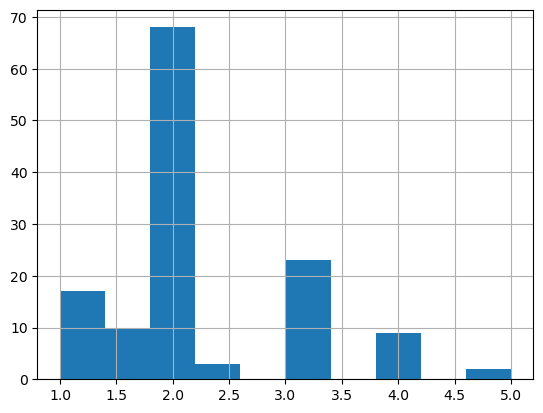

In [100]:
df['duration_hours'].hist()

### Core finding:

> The reservation dataset captures only a small subset of total demand, primarily larger groups, and does not represent the majority of customer traffic, which is walk-in based.

## 1. Group size vs duration

> “large reservation groups tend to stay 2–3 hours”

---

## 2. Group size by hour

> Reservations in early hours are dominated by larger parties, likely pre-planned events.

---

## 3. Duration histogram

> Most booked sessions are 2–3 hours → aligns with pricing structure

---

## SECTION: Data Limitations & Bias

### Data Coverage Limitation

The dataset used in this analysis only includes reservation records. Based on operational experience, the majority of customers are walk-ins, especially in the Berkeley location.

As a result:

* Peak hour analysis reflects **reservation demand**, not total demand
* Utilization is **significantly underestimated**
* Customer behavior is biased toward **larger group bookings**

---

### Business Implication

> Decisions based solely on reservation data may lead to incorrect conclusions about demand, staffing needs, and revenue opportunities.

## Insight: Walk-in driven business model

**Observation (experience):**

* Majority of customers are walk-ins

**Data limitation:**

* Not captured in dataset

**Impact:**

* Underestimation of demand
* Poor staffing planning

**Recommendation:**

* Track walk-ins (simple counter or POS integration)

---

## Insight: Unmonetized customer behavior

**Observation:**

* Customers bring outside food/drinks

**Problem:**

* No tracking → no revenue

**Recommendation:**

* Add tracking column
* Introduce corkage or bundles

---

## Insight: Revenue model opportunity

**Observation:**

* Drinks are underutilized revenue stream

**Recommendation:**

* Introduce bar / cocktails
* Happy hour targeting low-demand time


### “What data we NEED”

| Missing Data | Why it matters       | Business value    |
| ------------ | -------------------- | ----------------- |
| Walk-ins     | True demand          | staffing, pricing |
| Item sales   | Product optimization | revenue           |
| Customer ID  | retention            | marketing         |
| No-show flag | efficiency           | scheduling        |

**Not every business is trying to maximize revenue**

“Jaguar appears to prioritize customer experience and accessibility over strict revenue maximization, which shapes its operational decisions.”

---

> “Jaguar intentionally leaves pricing and ancillary revenue opportunities underexploited in order to maintain a low-friction, customer-friendly experience.”

---

> While many karaoke businesses monetize heavily through alcohol sales and corkage fees, Jaguar does not charge for outside food and drinks. This suggests a deliberate strategy to prioritize customer satisfaction and retention over short-term revenue maximization.

---

> Jaguar is operating under a “customer surplus maximization” model rather than pure profit maximization.

---

> While initial analysis focused on revenue and utilization, discussions with management suggest that Jaguar’s primary objective is not strict revenue maximization. Instead, the business emphasizes customer enjoyment and affordability, as reflected in policies such as allowing outside food and drinks without additional charges. This strategic choice likely reduces short-term revenue opportunities but may enhance long-term customer retention and brand loyalty.